# Lecture 1b: Introduction to Jupyter Notebooks, Google Colab and Matplotlib

[Data Visualization · 1-DAV-105](https://fmfi-compbio.github.io/viz/)

<!-- Lecture by Broňa Brejová -->


## Jupyter Notebook

* [Jupyter](https://jupyter.org/) Notebook is a web-based software for interactive work in Python.
* It is frequently used for data processing and visualization.
* A document called **notebook** consists of **cells**.
* Each cell contains either text or Python code.
* The text may include formatting in [Markdown](https://colab.research.google.com/notebooks/markdown_guide.ipynb) language.
* A cell with Python code can be executed and the results display below, including images.
* This presentation is a Jupyter notebook.
* Notebook files have extension `.ipynb`.


## Google Colab and alternatives

* You can work with Jupyter notebooks on many platforms (both online and installed on your computer).
* In this course, we will primarily use [Google Colaboratory](https://colab.research.google.com/) (Colab).
* Colab stores your notebooks on Google drive, executes them on Google servers, you only need a web browser on your computer.
* You are free to use other options as long as the submitted notebooks can be executed in Colab.
* One popular option is [VS Code](https://code.visualstudio.com/). It requires Jupyter software to be installed as well, see [documentation](https://code.visualstudio.com/docs/datascience/jupyter-notebooks).

## How to use Notebooks

* Notebooks have an intuitive interface with menus, toolbars, context menus (right-click) etc.
* It is useful to learn some keyboard shortcuts.

When you are not editting a cell:

* use Up and Down arrows to move between cells
* use **Enter** (or double-click) to start editing a cell
* use **Esc** to stop editing a cell
* use **Ctrl-Enter** to run a code in a cell, **Shift-Enter** to run the code and move to the next cell 

### An example of a code cell

* A cell can include imports, function definitions, commands.
* Variables will be visible in other cells.
* The results of `print` are shown below the cell when executed.
* The last expression is printed below the cell when executed.

In [1]:
# create variable x with list of numbers 0,1,...,19
x = list(range(20))
# variable y will contain squares of values in x
y = [xval * xval for xval in x]
# print x and y
print(x)
print(y)
# the last value in the cell is also printed automatically
y[0:5]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121, 144, 169, 196, 225, 256, 289, 324, 361]


[0, 1, 4, 9, 16]

### Example of a cell with a plot

The plot uses variables `x` and `y` from the previous cell to plot the quadratic function.

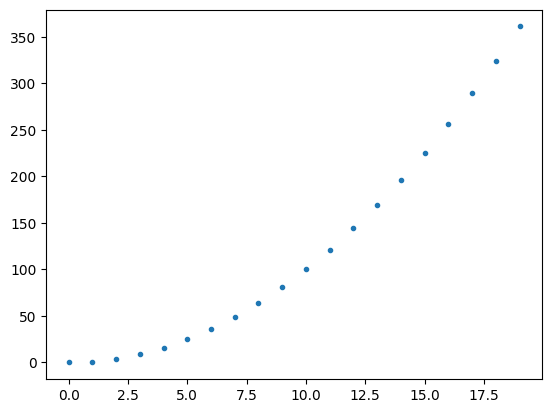

In [2]:
import matplotlib.pyplot as plt
# create figure with a single plot (axes)
figure, axes = plt.subplots()
# plot x vs y
axes.plot(x, y, '.')
# command pass to suppress unwanted output from plot
pass

## Matplotlib library

* [Matplotlib](https://matplotlib.org/) is a Python library for creating plots.
* In the code above, `axes` is the Matplotlib name for a single plot.
* Let us now plot two functions: quadratic and cubic in the same plot.

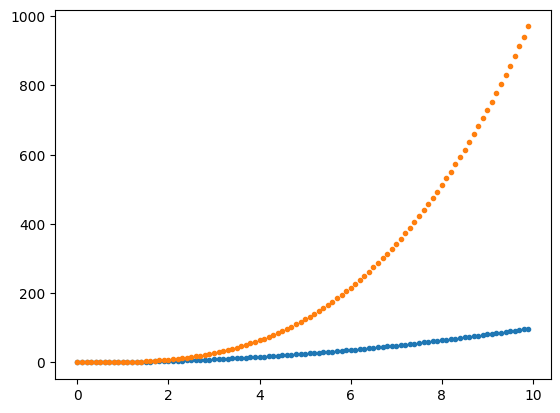

In [3]:
# x_dense is values from 0 to 10 with step 0.1
x_dense = [val / 10 for val in range(0, 100)]
# values in y2_dense are values from x_dense squared
y2_dense = [xval ** 2 for xval in x_dense]
# values in y3_dense are values from x_dense to the power of 3
y3_dense = [xval ** 3 for xval in x_dense]
# plot the quadratic and cubic function in a single plot
figure, axes = plt.subplots()
axes.plot(x_dense, y2_dense, '.')
axes.plot(x_dense, y3_dense, '.')
pass 

### Setting labels and titles in Matplotlib

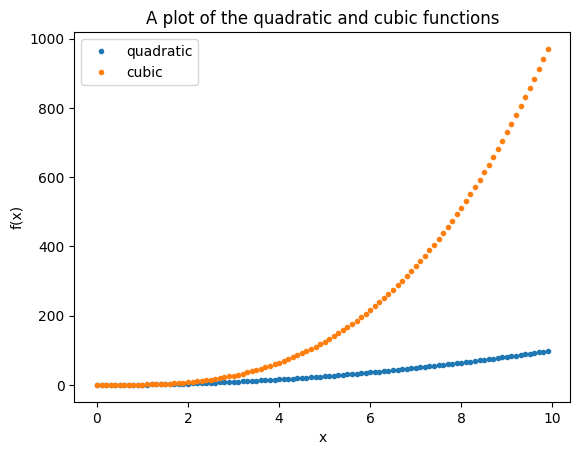

In [4]:
# the same plot as before, but name the two sets of points by label
figure, axes = plt.subplots()
axes.plot(x_dense, y2_dense, '.', label="quadratic")
axes.plot(x_dense, y3_dense, '.', label="cubic")

# add titles for axes (usually use a more descriptive titles)
axes.set_xlabel("x")  
axes.set_ylabel("f(x)")
# legend (which plot is which function), uses the labels set in axes.plot
axes.legend()  
# a title of the whole plot
axes.set_title("A plot of the quadratic and cubic functions")
pass 

### Setting lines, markers and colors

* In the `axes.plot` command, `'.'` represents formatting, in this case a small dot.
* The formatting string has three optional parts: marker, line, color.
* Examples: `'or'` red circle, `'-g'` green solid line, `'--'` dashed line.
* See more in [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html).



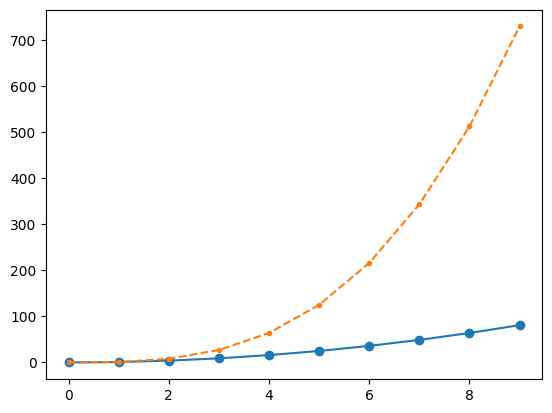

In [5]:
x_sparse = range(0, 10)
y2_sparse = [xval ** 2 for xval in x_sparse]
y3_sparse = [xval ** 3 for xval in x_sparse]
figure, axes = plt.subplots()
axes.plot(x_sparse, y2_sparse, 'o-')
axes.plot(x_sparse, y3_sparse, '.--')
pass

### Multiple plots per image
* Function [plt.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) can take as arguments the number of rows and the number of columns and creates multiple subplots per image.
* Why is this figure not an ideal visual comparison of the quadratic and cubic function?

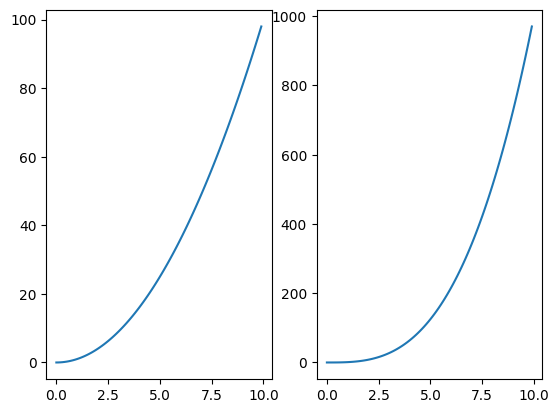

In [6]:
figure, axes = plt.subplots(1, 2)
axes[0].plot(x_dense, y2_dense)
axes[1].plot(x_dense, y3_dense)
pass

* Each plot has a different y-axis, which is not good, because we do not immediately see that the cubic function grows much faster than the quadratic.
* We will fix this in the next plot using `sharey=True` setting (`sharex=True` also exists but here it is not needed).


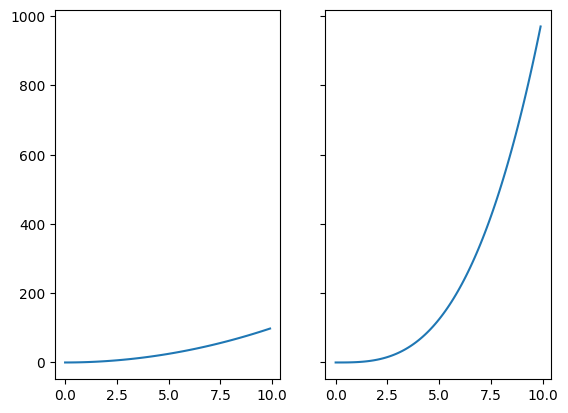

In [7]:
# fixing the problem with different y-axis
figure, axes = plt.subplots(1, 2, sharey=True)
axes[0].plot(x_dense, y2_dense)
axes[1].plot(x_dense, y3_dense)

# here we also save the figure to a file in a new directory "img"
import os
os.makedirs("img", exist_ok=True)
figure.savefig("img/L01b-plot1.png",  bbox_inches='tight')
pass

## Two technical notes

* If you work with files (as inputs or outputs of your notebook), you can upload or download them after clicking the folder icon on the right tab.
* Make sure to **disable AI assistants** when working on homeworks and group tasks. AI assistants will be allowed on the final project.

## Dangers of notebooks

* Frequent use pattern: the users have several cells finished and executed, they work on the last cell in the notebook, and run it repeatedly until it works correctly. This avoids repeated execution of the top cells, which may be slow.
* Notebooks do not force you to run cells in order from top to bottom. This generates problems if you skip some cells or execute them repeatedly.

Good practice suggestions:

* Avoid running cells out of order and occasionally restart the kernel (to remove variables) and run all cells (using a menu function).
* Do not modify variables introduced in other cells.
* Refactor bigger or repeated parts of code to functions. This also hides local variables from the rest of the notebook and thus prevents clashes.
* Ideally move functions to separate modules but this is harder in Colab.

Below we see an example not obeying the first two recommendations; the value printed will depened on how many times we execute the second cell. This can lead to hard-to-find errors in a more complex case.

In [8]:
value = 0

In [9]:
value += 1
print(value)

1


See also [I don't like notebooks](https://www.youtube.com/watch?v=7jiPeIFXb6U) by Joel Grus, an entertaining video explaining some of the pitfalls of notebooks

## Additional resources

* [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) by Jake VanderPlas, O'Reilly 2016
* [Jupyter Notebook documentation](https://jupyter-notebook.readthedocs.io/en/stable/)
* [Google Colab website](https://colab.research.google.com/) and [introductory video](https://www.youtube.com/watch?v=inN8seMm7UI)
* [Matplotlib tutorials](https://matplotlib.org/stable/tutorials/index.html)
* [I don't like notebooks](https://www.youtube.com/watch?v=7jiPeIFXb6U) by Joel Grus, an entertaining video explaining some of the pitfalls of notebooks 
